In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.pipeline import Pipeline

# Extracción del archivo creado

In [112]:
datos_procesados= pd.read_csv('datos_procesados.csv')
datos_procesados.sample(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
5418,7408-OFWXJ,No,Female,0,1,1,72,1,1,DSL,...,1,1,1,1,Two year,0,Credit card (automatic),89.80,6510.45,2.97
5514,7560-QJAVJ,No,Female,0,0,0,70,1,0,DSL,...,1,1,1,1,Two year,0,Bank transfer (automatic),79.60,5589.45,2.62
345,0504-HHAPI,Yes,Female,1,0,0,27,1,1,Fiber optic,...,1,0,0,1,Month-to-month,0,Credit card (automatic),88.30,2467.75,3.00
3253,4538-WNTMJ,No,Female,0,1,1,46,1,1,No,...,0 internet service,0 internet service,0 internet service,0 internet service,One year,0,Mailed check,24.95,1165.90,0.83
3951,5394-MEITZ,No,Female,0,1,1,60,1,0,DSL,...,1,1,1,1,Two year,1,Bank transfer (automatic),80.60,4946.70,2.71


# Eliminación de columnas irrelevantes

In [113]:
datos_procesados.drop(columns=["customerID"], axis=1, inplace=True)


In [114]:
datos_procesados

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.Daily
0,No,Female,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.17
1,No,Male,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.98
2,Yes,Male,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.31
3,Yes,Male,1,1,0,13,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.13
4,Yes,Female,1,1,0,3,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,No,Female,0,0,0,13,1,0,DSL,1,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.88
7263,Yes,Male,0,1,0,22,1,1,Fiber optic,0,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.80
7264,No,Male,0,0,0,2,1,0,DSL,0,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.52
7265,No,Male,0,1,1,67,1,0,DSL,1,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.27


In [115]:

columnas_categoricas = datos_procesados.select_dtypes(include=['object']).columns
datos_procesados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7267 non-null   object 
 1   gender            7267 non-null   object 
 2   SeniorCitizen     7267 non-null   int64  
 3   Partner           7267 non-null   int64  
 4   Dependents        7267 non-null   int64  
 5   tenure            7267 non-null   int64  
 6   PhoneService      7267 non-null   int64  
 7   MultipleLines     7267 non-null   int64  
 8   InternetService   7267 non-null   object 
 9   OnlineSecurity    7267 non-null   object 
 10  OnlineBackup      7267 non-null   object 
 11  DeviceProtection  7267 non-null   object 
 12  TechSupport       7267 non-null   object 
 13  StreamingTV       7267 non-null   object 
 14  StreamingMovies   7267 non-null   object 
 15  Contract          7267 non-null   object 
 16  PaperlessBilling  7267 non-null   int64  


#Encoding

In [116]:
datos_procesados=pd.get_dummies(datos_procesados, drop_first=True)
datos_procesados.drop(columns=["Churn_Unknown"], axis=1, inplace=True)

In [117]:
datos_procesados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7267 non-null   int64  
 1   Partner                                7267 non-null   int64  
 2   Dependents                             7267 non-null   int64  
 3   tenure                                 7267 non-null   int64  
 4   PhoneService                           7267 non-null   int64  
 5   MultipleLines                          7267 non-null   int64  
 6   PaperlessBilling                       7267 non-null   int64  
 7   Charges.Monthly                        7267 non-null   float64
 8   Charges.Total                          7267 non-null   float64
 9   Charges.Daily                          7267 non-null   float64
 10  Churn_Yes                              7267 non-null   bool   
 11  gend

In [118]:
cols_bool = datos_procesados.select_dtypes(include=['bool']).columns


In [119]:
datos_procesados[cols_bool] = datos_procesados[cols_bool].astype(np.int8)


In [120]:
datos_procesados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7267 non-null   int64  
 1   Partner                                7267 non-null   int64  
 2   Dependents                             7267 non-null   int64  
 3   tenure                                 7267 non-null   int64  
 4   PhoneService                           7267 non-null   int64  
 5   MultipleLines                          7267 non-null   int64  
 6   PaperlessBilling                       7267 non-null   int64  
 7   Charges.Monthly                        7267 non-null   float64
 8   Charges.Total                          7267 non-null   float64
 9   Charges.Daily                          7267 non-null   float64
 10  Churn_Yes                              7267 non-null   int8   
 11  gend

#Verificación de la Proporción de Cancelación (Churn)

In [121]:
columna_objetivo = 'Churn_Yes'
conteo_churn = datos_procesados[columna_objetivo].value_counts()
proporcion_churn = datos_procesados[columna_objetivo].value_counts(normalize=True) * 100
print(conteo_churn)
print(proporcion_churn)

Churn_Yes
0    5398
1    1869
Name: count, dtype: int64
Churn_Yes
0    74.280996
1    25.719004
Name: proportion, dtype: float64


/tmp/ipykernel_322/3981957315.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_churn.index, y=conteo_churn.values, palette='viridis')


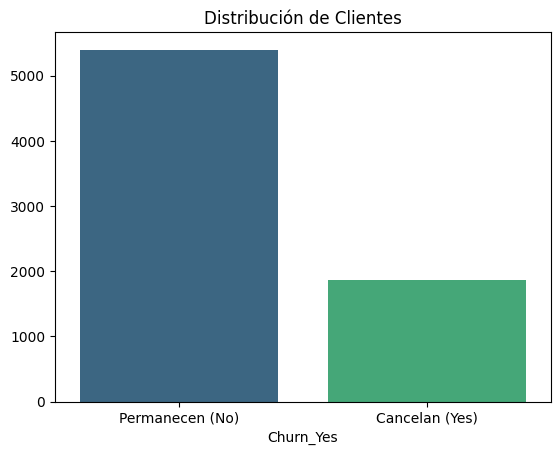

In [122]:
sns.barplot(x=conteo_churn.index, y=conteo_churn.values, palette='viridis')
plt.title('Distribución de Clientes')
plt.xticks([0, 1], ['Permanecen (No)', 'Cancelan (Yes)'])
plt.show()

# Balanceo de Clases (opcional)

In [123]:
X = datos_procesados.drop(columns=['Churn_Yes']) # target
y = datos_procesados['Churn_Yes']
y

,Churn_Yes
0,0
1,0
2,1
3,1
4,1
...,...
7262,0
7263,1
7264,0
7265,0


In [124]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [125]:
print(y.value_counts(normalize=True))

Churn_Yes
0    0.74281
1    0.25719
Name: proportion, dtype: float64


In [126]:
print(pd.Series(y_resampled).value_counts(normalize=True))

Churn_Yes
0    0.5
1    0.5
Name: proportion, dtype: float64


In [127]:
df_balanceado = pd.DataFrame(X_resampled, columns=X.columns)
df_balanceado['Churn_Yes'] = y_resampled
df_balanceado

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,PaperlessBilling,Charges.Monthly,Charges.Total,Charges.Daily,...,StreamingTV_0 internet service,StreamingTV_1,StreamingMovies_0 internet service,StreamingMovies_1,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,1,9,1,0,1,65.600000,593.300000,2.170000,...,0,1,0,0,1,0,0,0,1,0
1,0,0,0,9,1,1,0,59.900000,542.400000,1.980000,...,0,0,0,1,0,0,0,0,1,0
2,0,0,0,4,1,0,1,73.900000,280.850000,2.310000,...,0,0,0,0,0,0,0,1,0,1
3,1,1,0,13,1,0,1,98.000000,1237.850000,3.130000,...,0,1,0,1,0,0,0,1,0,1
4,1,1,0,3,1,0,1,83.900000,267.400000,2.930000,...,0,1,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10791,0,0,0,30,1,0,1,76.085770,2220.191736,2.429483,...,0,0,0,0,0,0,0,1,0,1
10792,0,0,0,15,0,0,0,41.464615,597.028129,1.352015,...,0,0,0,0,0,0,0,0,0,1
10793,1,1,0,53,1,1,0,102.978528,5431.175363,3.335398,...,0,0,0,1,0,0,0,0,0,1
10794,0,0,0,6,1,1,0,82.387399,476.190024,2.525024,...,0,0,0,0,0,0,0,0,0,1


# Estandarización

In [128]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [129]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [130]:
#datos_procesados.info()
cols_a_escalar = ['tenure', 'Charges.Monthly', 'Charges.Total','Charges.Daily']
scaler = StandardScaler()

In [131]:
# AJUSTAR Y TRANSFORMAR TRAIN
X_train_resampled[cols_a_escalar] = scaler.fit_transform(X_train_resampled[cols_a_escalar])

# TRANSFORMAR TEST: Usamos la media y desv. estándar APRENDIDAS DEL TRAIN
X_test[cols_a_escalar] = scaler.transform(X_test[cols_a_escalar])

#X_train_resampled[cols_a_escalar].describe().round(2)
#y_train_resampled.value_counts(normalize=True).round(2)
#y_test.value_counts(normalize=True).round(2)

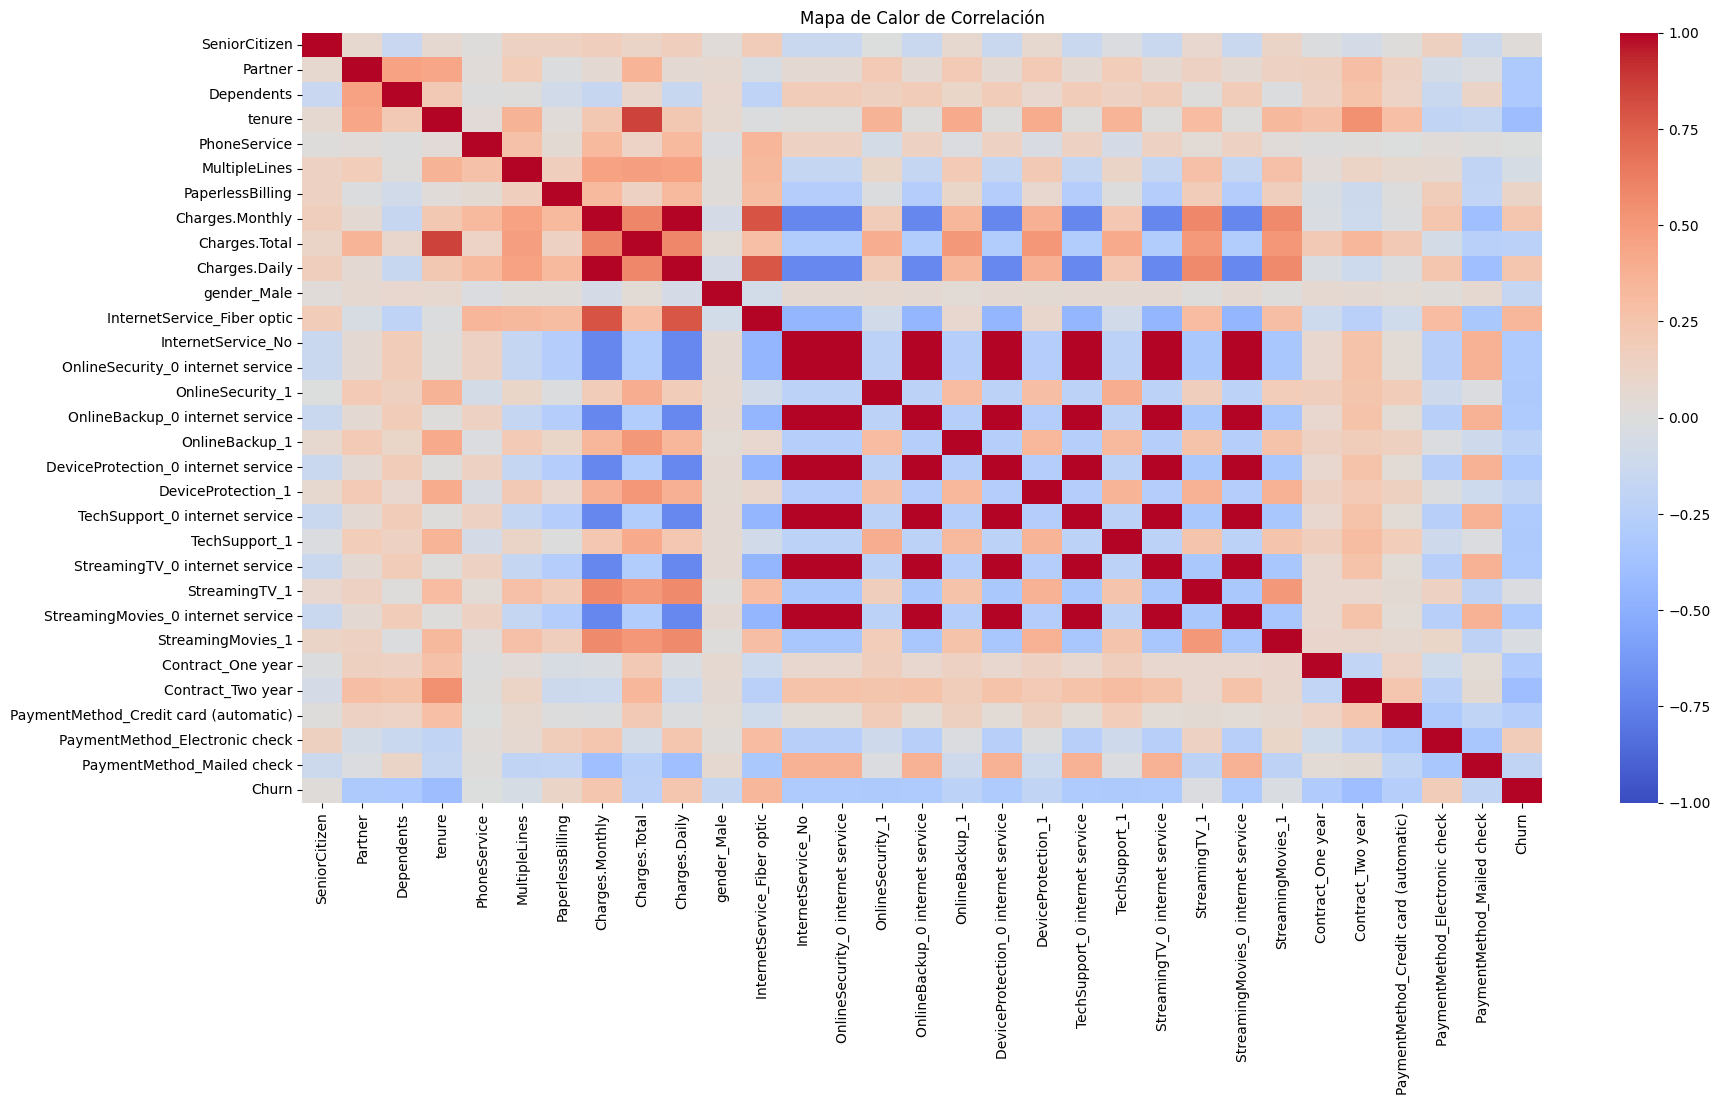

In [132]:
df_corr = X_train_resampled.copy()
df_corr['Churn'] = y_train_resampled

matriz_corr = df_corr.corr()

plt.figure(figsize=(20, 10))
sns.heatmap(matriz_corr, annot=False, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlación')
plt.show()

# Análisis Dirigido

/tmp/ipykernel_322/2622617544.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Yes', y='tenure', data=datos_procesados, palette='Set2')


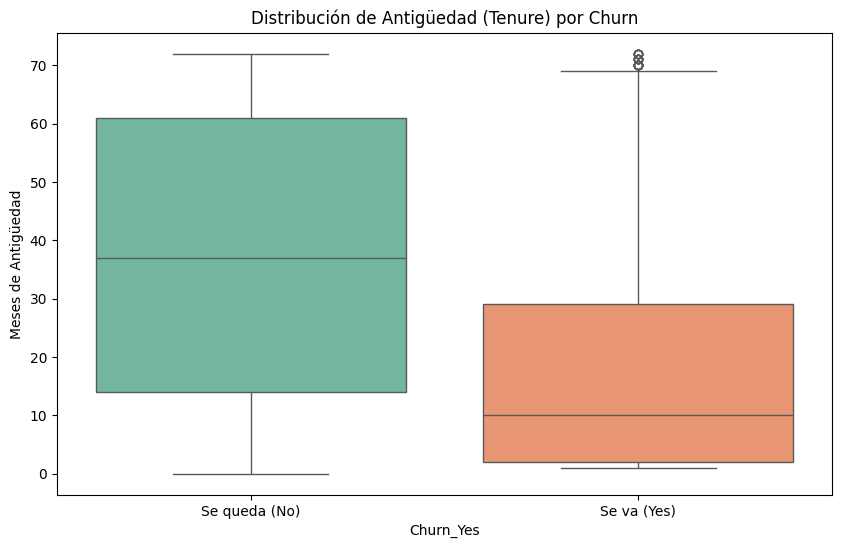

In [133]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn_Yes', y='tenure', data=datos_procesados, palette='Set2')
plt.title('Distribución de Antigüedad (Tenure) por Churn')
plt.xticks([0, 1], ['Se queda (No)', 'Se va (Yes)'])
plt.ylabel('Meses de Antigüedad')
plt.show()

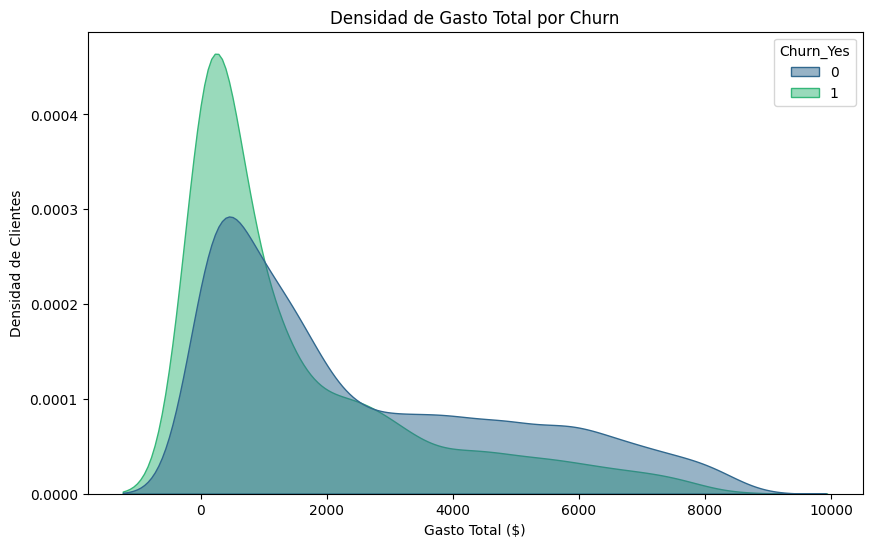

In [134]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=datos_procesados, x='Charges.Total', hue='Churn_Yes', fill=True, common_norm=False, palette='viridis', alpha=0.5)
plt.title('Densidad de Gasto Total por Churn')
plt.xlabel('Gasto Total ($)')
plt.ylabel('Densidad de Clientes')
plt.show()

In [135]:
#plt.figure(figsize=(12, 7))
# Asumiendo que tienes una columna 'Contract' original
#sns.violinplot(x='Contract', y='Charges.Total', hue='Churn_Yes', data=df_corr, split=True, palette='Pastel1')
#plt.title('Gasto Total vs Tipo de Contrato y Churn')
#plt.show()

#df_corr

# Separación de Datos

In [136]:
X = datos_procesados.drop(columns=['Churn_Yes']) # Características
y = datos_procesados['Churn_Yes']                # Objetivo

# 2. Realizamos la división (Split)
# test_size=0.20 -> 20% para prueba, 80% para entrenamiento
# random_state=42 -> Para que el resultado sea reproducible (siempre el mismo split) -> stratify=y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


# Creación de modelos

## Regresión Logística

In [137]:
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_resampled, y_train_resampled)

LogisticRegression(random_state=42)

In [138]:
y_pred_log = log_model.predict(X_test)
y_pred_log


array([1, 1, 1, ..., 1, 1, 1], dtype=int8)

In [139]:

print(classification_report(y_test, y_pred_log))
## No detecta los ceros¿¿¿¿

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1080
           1       0.26      1.00      0.41       374

    accuracy                           0.26      1454
   macro avg       0.13      0.50      0.20      1454
weighted avg       0.07      0.26      0.11      1454



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [140]:
print("Conteo de clases en Entrenamiento:", y_train_resampled.value_counts())

Conteo de clases en Entrenamiento: Churn_Yes
0    4318
1    4318
Name: count, dtype: int64


In [141]:
cols_a_eliminar = ['Churn_Unknown'] ## Columna basura, engaña al modelo?


X_train_resampled = X_train_resampled.drop(columns=cols_a_eliminar, errors='ignore')
X_test = X_test.drop(columns=cols_a_eliminar, errors='ignore')

In [142]:
X_train_resampled.columns.tolist()

['SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'PaperlessBilling',
 'Charges.Monthly',
 'Charges.Total',
 'Charges.Daily',
 'gender_Male',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_0 internet service',
 'OnlineSecurity_1',
 'OnlineBackup_0 internet service',
 'OnlineBackup_1',
 'DeviceProtection_0 internet service',
 'DeviceProtection_1',
 'TechSupport_0 internet service',
 'TechSupport_1',
 'StreamingTV_0 internet service',
 'StreamingTV_1',
 'StreamingMovies_0 internet service',
 'StreamingMovies_1',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [143]:
X_test = X_test[X_train_resampled.columns]

log_model_final = LogisticRegression(max_iter=1000, random_state=42)
log_model_final.fit(X_train_resampled, y_train_resampled)

#Probamos la nueva predicción
y_pred_final = log_model_final.predict(X_test)

In [144]:
print(classification_report(y_test, y_pred_final)) # ¿

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1080
           1       0.26      1.00      0.41       374

    accuracy                           0.26      1454
   macro avg       0.13      0.50      0.20      1454
weighted avg       0.07      0.26      0.11      1454



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [145]:
correlaciones = X_train_resampled.corrwith(pd.Series(y_train_resampled))
print("--- Top 5 Variables con Correlación Extrema ---")
print(correlaciones.sort_values(ascending=False).head(10))

print("\n--- Resumen estadístico de X_test (primeras 5 columnas) ---")
print(X_test.iloc[:, :5].describe().loc[['mean', 'max', 'min']])

--- Top 5 Variables con Correlación Extrema ---
InternetService_Fiber optic       0.336029
Charges.Monthly                   0.241969
Charges.Daily                     0.241717
PaymentMethod_Electronic check    0.192989
PaperlessBilling                  0.114251
SeniorCitizen                     0.016773
PhoneService                     -0.007247
StreamingTV_1                    -0.019350
StreamingMovies_1                -0.027723
MultipleLines                    -0.050750
dtype: float64

--- Resumen estadístico de X_test (primeras 5 columnas) ---
      SeniorCitizen  Partner  Dependents     tenure  PhoneService
mean       0.155433  0.48762    0.311554  31.643741      0.901651
max        1.000000  1.00000    1.000000  72.000000      1.000000
min        0.000000  0.00000    0.000000   0.000000      0.000000


In [146]:
#y_test.value_counts()
X_train_resampled.columns.tolist()


['SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'PaperlessBilling',
 'Charges.Monthly',
 'Charges.Total',
 'Charges.Daily',
 'gender_Male',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_0 internet service',
 'OnlineSecurity_1',
 'OnlineBackup_0 internet service',
 'OnlineBackup_1',
 'DeviceProtection_0 internet service',
 'DeviceProtection_1',
 'TechSupport_0 internet service',
 'TechSupport_1',
 'StreamingTV_0 internet service',
 'StreamingTV_1',
 'StreamingMovies_0 internet service',
 'StreamingMovies_1',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [162]:
pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42))
])

pipeline_final.fit(X_train, y_train)

#Predicción
y_pred_final = pipeline_final.predict(X_test)

In [165]:

print(classification_report(y_test, y_pred_final))
print("Valores predichos:", np.unique(y_pred_final))


              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1080
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1454
   macro avg       0.71      0.77      0.71      1454
weighted avg       0.81      0.74      0.76      1454

Valores predichos: [0 1]


## Random forest

In [149]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

In [150]:
y_pred_rf = rf_model.predict(X_test)
y_pred_rf

array([0, 1, 0, ..., 1, 1, 0], dtype=int8)

In [151]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.72      0.79      1080
           1       0.47      0.70      0.56       374

    accuracy                           0.72      1454
   macro avg       0.67      0.71      0.68      1454
weighted avg       0.77      0.72      0.73      1454



# Evaluación de modelos

## Regresión Logística

In [152]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [153]:
y_pred_log = pipeline_final.predict(X_test)

In [154]:
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_log):.2f}")
print(f"Precisión:           {precision_score(y_test, y_pred_log):.2f}")
print(f"Recall (Sensibilidad): {recall_score(y_test, y_pred_log):.2f}")
print(f"F1-Score:            {f1_score(y_test, y_pred_log):.2f}")

Exactitud (Accuracy): 0.74
Precisión:           0.50
Recall (Sensibilidad): 0.81
F1-Score:            0.62


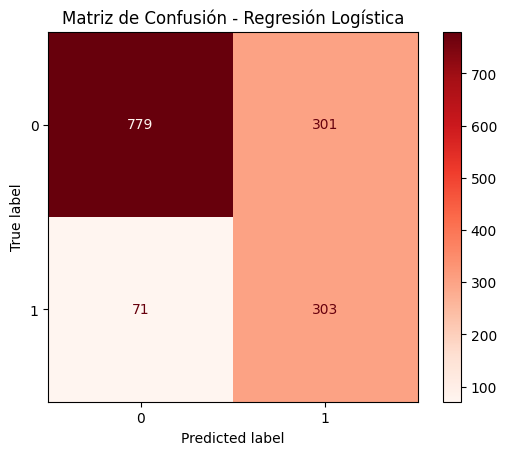

In [155]:
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp_log.plot(cmap='Reds')
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

## Random Forest

In [156]:
y_pred_rf = rf_model.predict(X_test)

print("--- MÉTRICAS: RANDOM FOREST ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_rf):.2f}")
print(f"Precisión:           {precision_score(y_test, y_pred_rf):.2f}")
print(f"Recall (Sensibilidad): {recall_score(y_test, y_pred_rf):.2f}")
print(f"F1-Score:            {f1_score(y_test, y_pred_rf):.2f}")

--- MÉTRICAS: RANDOM FOREST ---
Exactitud (Accuracy): 0.72
Precisión:           0.47
Recall (Sensibilidad): 0.70
F1-Score:            0.56


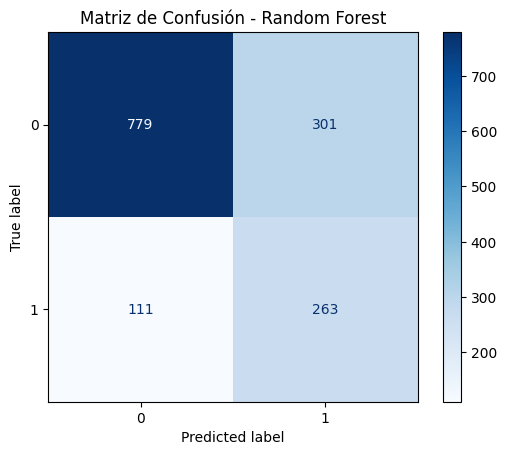

In [157]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap='Blues')
plt.title("Matriz de Confusión - Random Forest")
plt.show()

## Análisis comparativo

De acuerdo a los modelos realizados podemos decir que la Regresión Logística sería el modelo recomendado. Aunque presenta un ligero underfitting en la etapa de entrenamiento debido al ruido del balanceo de datos, muestra valores superiores en el conjunto de prueba con un Recall del 81%. Esto garantiza que la mayoría de los clientes en riesgo sean identificados, permitiendo acciones de retención oportunas.

# Análisis de la Importancia de las Variables

## Regresión Logística

In [158]:
coeficientes = pipeline_final.named_steps['clf'].coef_[0]
nombres_variables = X_train.columns


df_importancia_log = pd.DataFrame({'Variable': nombres_variables, 'Coeficiente': coeficientes})
df_importancia_log = df_importancia_log.sort_values(by='Coeficiente', ascending=False)

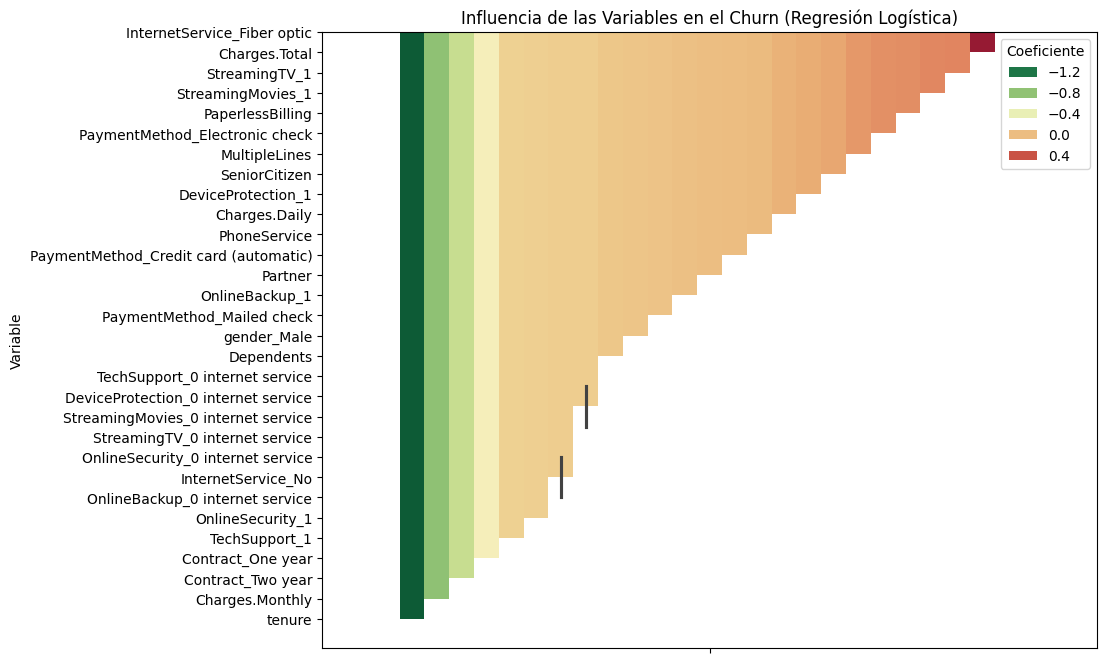

In [159]:
plt.figure(figsize=(10, 8))
sns.barplot(hue='Coeficiente', y='Variable', data=df_importancia_log, palette='RdYlGn_r')
plt.title('Influencia de las Variables en el Churn (Regresión Logística)')
plt.show()

## Random Forest

In [160]:
importancias_rf = rf_model.feature_importances_

df_importancia_rf = pd.DataFrame({'Variable': nombres_variables, 'Importancia': importancias_rf})
df_importancia_rf = df_importancia_rf.sort_values(by='Importancia', ascending=False)

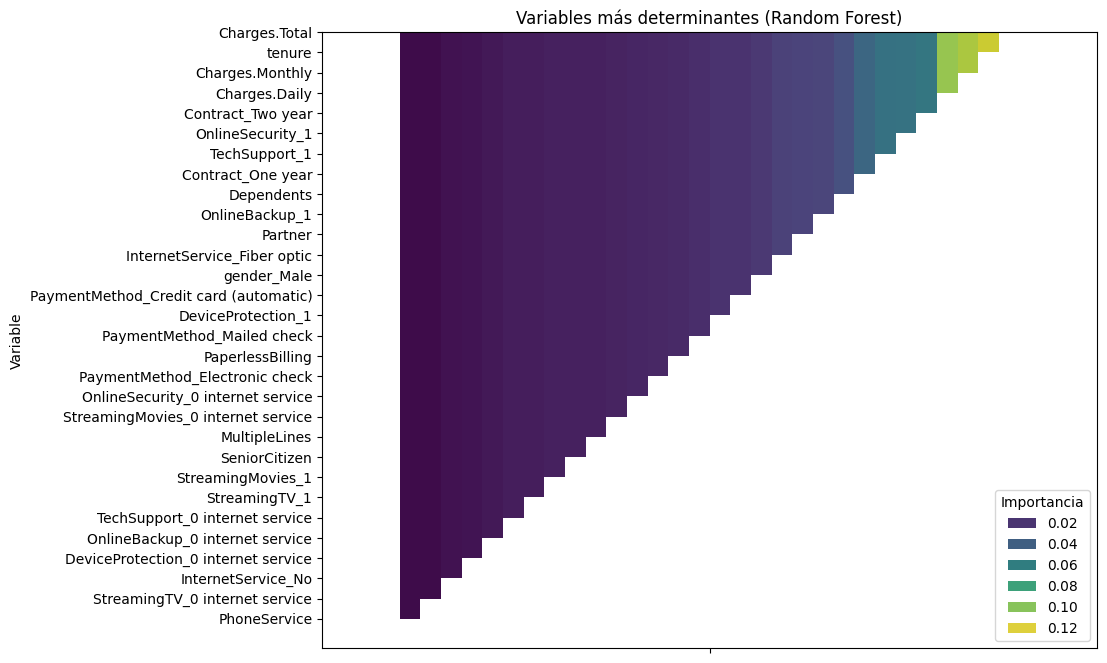

In [161]:
plt.figure(figsize=(10, 8))
sns.barplot(hue='Importancia', y='Variable', data=df_importancia_rf, palette='viridis')
plt.title('Variables más determinantes (Random Forest)')
plt.show()

# Conclusiones

Para este análisis, se compararon dos arquitecturas distintas: Regresión Logística (modelo lineal balanceado mediante Pipeline) y Random Forest (modelo basado en árboles).

- Modelo Ganador: La Regresión Logística demostró ser el modelo más eficaz para los objetivos de negocio.

- Recall: Alcanzó un 81% de Sensibilidad (Recall), superando al 70% del Random Forest. Esto significa que la Regresión Logística es capaz de identificar a 8 de cada 10 clientes que realmente planean cancelar.

- Exactitud General: Ambos modelos mostraron un rendimiento sólido en el conjunto de prueba (74% para Regresión Logística), confirmando que el modelo es capaz de generalizar sus predicciones a nuevos clientes.

## Factores de cancelación

Basandonos en la importancia de las variables y los coeficientes de los modelos, hemos identificado tres pilares que definen el comportamiento del churn:

- Servicio de fibra óptica: La variable InternetService_FiberOptic fue el predictor positivo de Churn más fuerte. Los clientes en este segmento tienen una tendencia significativamente mayor a abandonar la empresa, posiblemente por insatisfacción con el precio o problemas técnicos no resueltos.

- Antiguedad: El riesgo de cancelación disminuye drásticamente a medida que el cliente supera los primeros meses de servicio y cuando está vinculado a un contrato de permanencia.

- Cargos: Charges.Total y Charges.Monthly dominaron la importancia en ambos modelos. La decisión de cancelar pudo ser financiera. El costo acumulado es el indicador principal que utiliza el modelo para separar a un cliente leal de uno en riesgo.

## Propuestas de corrección

- Servicio de Fibra óptica: Es urgente revisar la propuesta de valor de la Fibra Óptica. Si es el principal impulsor de cancelaciones, se debe investigar si existe un problema de estabilidad en la red o si la competencia ofrece precios significativamente menores por la misma tecnología.

- Programa de antiguedad: Dado que el ternure predice la fuga, se debe implementar un protocolo de seguimiento intensivo durante los primeros 3 a 6 meses del cliente.

- Carga financiera: Utilizar el modelo para identificar clientes cuyos cargos mensuales hayan subido mucho en poco tiempo. Esto podría ir de la mano del programa de antiguedad, ofrecer buenos servicios a costos menores durante un periodo de tiempo determinado para aminorar el peso al bolsillo del cliente y generar confianza en el cliente.